# Toxic Search Model Training Experiments

This notebook provides a comprehensive training pipeline for the toxic_search model with different configurations and hyperparameters.

## 📋 Quick Start Guide

**For first-time users:**
1. Run cells 1-8 sequentially to setup, load data, and generate triplets
2. Customize experiment configurations in Section 5 (cell 12)
3. Run Section 9 (cell 20) to train and evaluate models
4. Review results in Sections 10-12

**For advanced users:**
- Section 14 contains additional experimental configurations
- Section 15 provides hyperparameter impact analysis
- Section 16 summarizes results and recommendations

## 📖 Outline

1. **Setup and Environment** - Import libraries and configure environment
2. **Data Loading and Exploration** - Load dataset and analyze distribution
3. **Generate Training Triplets** - Create triplet examples for training
4. **Baseline Configuration** - Review default hyperparameters
5. **Experiment Configurations** - Define hyperparameter variations
6. **Training Function** - Define training and evaluation pipeline
7. **Run Experiments** - (Placeholder - see Section 9)
8. **Model Evaluation** - Evaluation function with retrieval metrics
9. **Run Full Training Pipeline** - Execute training with evaluation
10. **Results Comparison** - Compare experiments with visualizations
11. **Best Model Selection** - Identify and save best performing model
12. **Test Set Evaluation** - Final evaluation on held-out test set
13. **Qualitative Analysis** - Test model with sample queries
14. **Advanced Experiments** - Additional hyperparameter configurations
15. **Hyperparameter Impact** - Analyze parameter effects on performance
16. **Summary and Recommendations** - Final summary and next steps

## 🎯 Key Features

- **Multiple Configurations**: Baseline + 5 standard + 5 advanced experiment configs
- **Comprehensive Metrics**: Precision@K, Recall@K, MAP, MRR
- **Automatic Best Model Selection**: Based on MAP score
- **Rich Visualizations**: Performance comparisons and hyperparameter impact
- **Reproducibility**: Automatic saving of configs, metrics, and model checkpoints


## 1. Setup and Environment


In [1]:
import sys
from pathlib import Path

# Add src to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from loguru import logger
from tqdm.auto import tqdm
import json

# Toxic search imports
from toxic_search.data.loader import load_dataset, split_dataset
from toxic_search.data.triplets import TripletGenerator
from toxic_search.models.encoder import load_encoder, ToxicEncoder
from toxic_search.training.trainer import train
from toxic_search.config import get_config, TrainingConfig, ModelConfig

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")


/Users/mfauzanazhim/Github/indonesian-hate-speech-detection/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.9.0
Device: cpu


## 2. Data Loading and Exploration


In [3]:
# Load the dataset
DATA_PATH = project_root / "dataset" / "indonesian_hate_speech.csv"
TEXT_COL = "text"
LABEL_COL = "labels"

df = load_dataset(DATA_PATH, text_column=TEXT_COL, label_column=LABEL_COL)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()


2025-11-24 06:22:55.788 | INFO     | toxic_search.data.loader:load_dataset:38 - Loaded 14306 samples from /Users/mfauzanazhim/Github/indonesian-hate-speech-detection/dataset/indonesian_hate_speech.csv


Dataset shape: (14306, 5)

Columns: ['text', 'labels', 'source', 'dataset', 'nb_annotators']

First few rows:


,text,labels,source,dataset,nb_annotators
0,@USER.wood17 knp lo gak berani bersumpah dan b...,1,Instagram,ID_instagram,3
1,"haha, somad somad. Muka dekil otak 0% , kok ya...",1,Instagram,ID_instagram,3
2,"hahaha, kaum sableng 212 kl berita begini mrk ...",1,Instagram,ID_instagram,3
3,"hahaha, makin stress aja ni umat sableng, dlu...",1,Instagram,ID_instagram,3
4,HIDUP PSI = partai SAMPAH indonesia..... ...,1,Instagram,ID_instagram,3


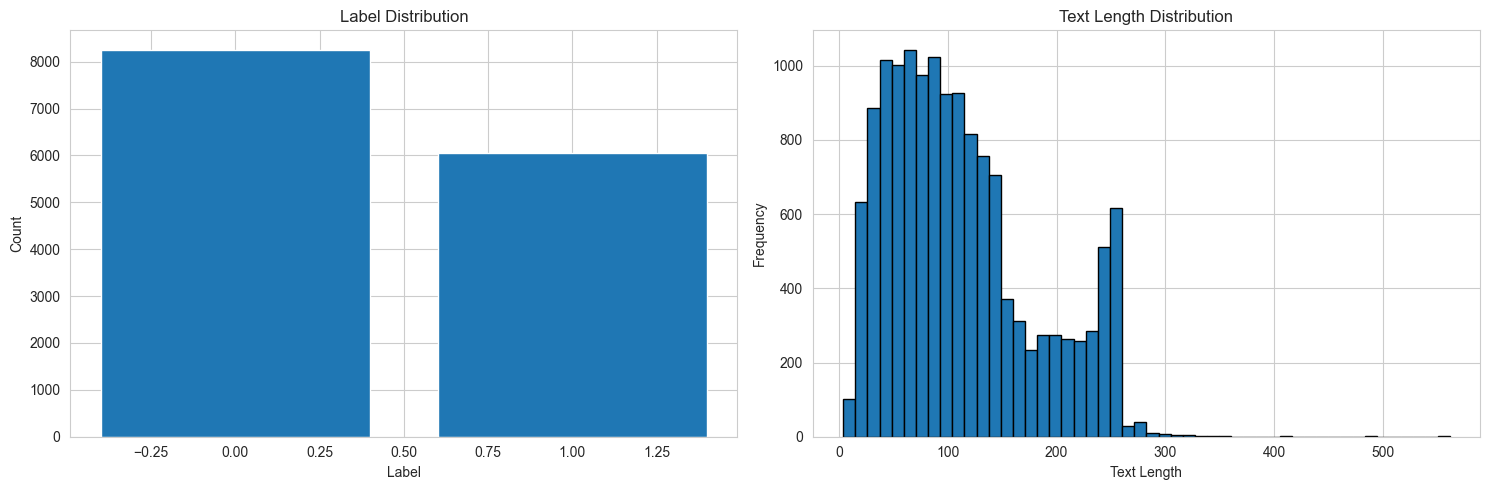


Label distribution:
labels
0    8256
1    6050
Name: count, dtype: int64

Text length stats:
count    14306.000000
mean       112.587725
std         68.069580
min          4.000000
25%         59.000000
50%         99.000000
75%        147.000000
max        561.000000
Name: text_length, dtype: float64


In [4]:
# Data distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Label distribution
label_counts = df[LABEL_COL].value_counts()
axes[0].bar(label_counts.index, label_counts.values)
axes[0].set_title("Label Distribution")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")

# Text length distribution
df['text_length'] = df[TEXT_COL].str.len()
axes[1].hist(df['text_length'], bins=50, edgecolor='black')
axes[1].set_title("Text Length Distribution")
axes[1].set_xlabel("Text Length")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(f"\nLabel distribution:")
print(label_counts)
print(f"\nText length stats:")
print(df['text_length'].describe())


In [5]:
# Split dataset
train_df, val_df, test_df = split_dataset(
    df,
    train_size=0.7,
    val_size=0.15,
    test_size=0.15,
    stratify_column=LABEL_COL,
    random_state=42
)

print(f"Train size: {len(train_df)}")
print(f"Val size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

# Save splits for reproducibility
splits_path = project_root / "artifacts" / "toxic_search" / "splits"
splits_path.mkdir(parents=True, exist_ok=True)

train_df.to_csv(splits_path / "train.csv", index=False)
val_df.to_csv(splits_path / "val.csv", index=False)
test_df.to_csv(splits_path / "test.csv", index=False)

print(f"\nSplits saved to {splits_path}")


2025-11-24 06:22:58.446 | INFO     | toxic_search.data.loader:split_dataset:78 - Split: train=10014, val=2146, test=2146


Train size: 10014
Val size: 2146
Test size: 2146

Splits saved to /Users/mfauzanazhim/Github/indonesian-hate-speech-detection/artifacts/toxic_search/splits


## 3. Generate Training Triplets


In [6]:
# Generate triplets for training
print("Generating training triplets...")
train_gen = TripletGenerator(train_df, TEXT_COL, LABEL_COL)

train_triplets = []
for batch in tqdm(train_gen.generate(batch_size=1000), desc="Generating triplets"):
    train_triplets.extend(batch)

print(f"\nGenerated {len(train_triplets)} training triplets")

# Sample triplets
print("\nSample triplets:")
for i, triplet in enumerate(train_triplets[:3]):
    print(f"\nTriplet {i+1}:")
    print(f"  Anchor: {triplet.anchor[:80]}...")
    print(f"  Positive: {triplet.positive[:80]}...")
    print(f"  Negative: {triplet.negative[:80]}...")


Generating training triplets...


Generating triplets: 11it [00:11,  1.07s/it]


Generated 10014 training triplets

Sample triplets:

Triplet 1:
  Anchor: USER USER Apa sih yg ga mau dikuasai oleh onta pengecut itu? Pasti ada aja hub n...
  Positive: USER USER banyak cocot. diem aja lu. komplotan tkng ngalus ama pelakor aja lu du...
  Negative: RT @USER: Bagaimana metode penarikan sampel hitung cepat yg dilakukan Litbang Ko...

Triplet 2:
  Anchor: monyet lu songong. URL...
  Positive: 43. Contoh lain: meski banyak tudingan dugaan korupsi tapi SBY tdk pernah dorong...
  Negative: Pak ahok, saya mempunyai ibu, ibu saya selalu mendoakan pak ahok setiap waktu da...

Triplet 3:
  Anchor: USER Rezim penguasa yg jd korban pers rezim SBY...
  Positive: USER USER Alhamdulillah akhirnya lo nyadar klw cebong pinter dan lucu..beda bang...
  Negative: #CNNIndonesia; Presiden Jokowi mencoret 14 proyek dari daftar setelah memutuskan...


## 4. Baseline Configuration


In [7]:
# Load default configuration
config = get_config()

print("Default Model Configuration:")
print(f"  Base model: {config.model.base_model}")
print(f"  Max seq length: {config.model.max_seq_length}")
print(f"  Embedding dim: {config.model.embedding_dim}")
print(f"  Distance metric: {config.model.distance_metric}")

print("\nDefault Training Configuration:")
print(f"  Batch size: {config.training.batch_size}")
print(f"  Epochs: {config.training.num_epochs}")
print(f"  Learning rate: {config.training.learning_rate}")
print(f"  Warmup steps: {config.training.warmup_steps}")
print(f"  Margin: {config.training.margin}")
print(f"  FP16: {config.training.fp16}")


Default Model Configuration:
  Base model: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
  Max seq length: 128
  Embedding dim: 768
  Distance metric: cosine

Default Training Configuration:
  Batch size: 32
  Epochs: 3
  Learning rate: 2e-05
  Warmup steps: 100
  Margin: 0.5
  FP16: True


### Understanding the Metrics

This training pipeline uses **retrieval-based metrics** (not classification metrics) because the toxic_search model is designed for semantic similarity search, not classification.

**Key Metrics:**

- **Precision@K**: What percentage of the top-K retrieved results have the same label as the query?
  - *Precision@1*: Is the most similar item the same label? (most important for search)
  - *Precision@5*: Of the top 5 results, how many match?
  - *Precision@10*: Of the top 10 results, how many match?

- **Recall@K**: Of all items with the same label, what percentage are in the top-K results?
  - Higher recall means the model finds more relevant items

- **MAP (Mean Average Precision)**: Average precision across all queries
  - **Primary metric for model selection**
  - Considers both precision and ranking quality
  - Higher is better (range: 0-1)

- **MRR (Mean Reciprocal Rank)**: Average of 1/rank of first correct result
  - Measures how quickly users find relevant results
  - Important for user experience

**Training Strategy:**

The model uses **triplet loss** to learn embeddings where:
- Similar texts (same label) are close together in embedding space
- Different texts (different labels) are pushed apart
- The `margin` parameter controls the minimum distance between positive and negative pairs


### Hyperparameter Guide

**`batch_size`** (default: 32)
- Number of triplets processed together
- Larger = faster training but more GPU memory
- Smaller = more stable gradients but slower
- *Try*: 16, 32, 64, 128

**`num_epochs`** (default: 3)
- How many times to iterate through entire dataset
- More epochs = more learning but risk overfitting
- *Try*: 2-5 for initial experiments, 5-10 for fine-tuning

**`learning_rate`** (default: 2e-5)
- How fast the model parameters update
- Too high = unstable training, too low = slow convergence
- *Try*: 1e-6 (very conservative), 1e-5 (safe), 2e-5 (standard), 5e-5 (aggressive)

**`margin`** (default: 0.5)
- Minimum distance between positive and negative pairs
- Larger margin = stricter separation between classes
- Smaller margin = more lenient, finer distinctions
- *Try*: 0.2 (small), 0.5 (standard), 1.0 (large), 1.5 (very large)

**`warmup_steps`** (default: 100)
- Number of steps to gradually increase learning rate
- Prevents unstable training at start
- More warmup = more conservative start
- *Try*: 50 (quick), 100 (standard), 200-500 (careful)

**`fp16`** (default: True)
- Use mixed precision training (faster, less memory)
- Set to False if encountering numerical instability


## 5. Experiment Configurations

We'll test different hyperparameter combinations to find the best configuration.


In [8]:
# Define experiment configurations
experiments = {
    "baseline": {
        "batch_size": 32,
        "num_epochs": 3,
        "learning_rate": 2e-5,
        "margin": 0.5,
        "warmup_steps": 100,
    },
    "high_margin": {
        "batch_size": 32,
        "num_epochs": 3,
        "learning_rate": 2e-5,
        "margin": 1.0,  # Larger margin
        "warmup_steps": 100,
    },
    "low_lr": {
        "batch_size": 32,
        "num_epochs": 3,
        "learning_rate": 1e-5,  # Lower learning rate
        "margin": 0.5,
        "warmup_steps": 100,
    },
    "large_batch": {
        "batch_size": 64,  # Larger batch
        "num_epochs": 3,
        "learning_rate": 2e-5,
        "margin": 0.5,
        "warmup_steps": 100,
    },
    "more_epochs": {
        "batch_size": 32,
        "num_epochs": 5,  # More training
        "learning_rate": 2e-5,
        "margin": 0.5,
        "warmup_steps": 100,
    },
    "warm_start": {
        "batch_size": 32,
        "num_epochs": 3,
        "learning_rate": 2e-5,
        "margin": 0.5,
        "warmup_steps": 500,  # More warmup
    },
}

print(f"Configured {len(experiments)} experiments:")
for name in experiments:
    print(f"  - {name}")


Configured 6 experiments:
  - baseline
  - high_margin
  - low_lr
  - large_batch
  - more_epochs
  - warm_start


In [9]:
# Visualize experiment configurations
import pandas as pd

# Create comparison table
config_comparison = pd.DataFrame.from_dict(experiments, orient='index')
config_comparison.index.name = 'Experiment'
config_comparison = config_comparison.reset_index()

print("=" * 100)
print("EXPERIMENT CONFIGURATIONS COMPARISON")
print("=" * 100)
display(config_comparison)

# Highlight differences from baseline
print("\nDifferences from Baseline:")
print("-" * 100)
baseline_config = experiments['baseline']
for exp_name, config in experiments.items():
    if exp_name != 'baseline':
        diffs = []
        for key, value in config.items():
            if value != baseline_config[key]:
                diffs.append(f"{key}: {baseline_config[key]} → {value}")
        if diffs:
            print(f"\n{exp_name}:")
            for diff in diffs:
                print(f"  • {diff}")


EXPERIMENT CONFIGURATIONS COMPARISON


,Experiment,batch_size,num_epochs,learning_rate,margin,warmup_steps
0,baseline,32,3,0.00002,0.5,100
1,high_margin,32,3,0.00002,1.0,100
2,low_lr,32,3,0.00001,0.5,100
3,large_batch,64,3,0.00002,0.5,100
4,more_epochs,32,5,0.00002,0.5,100
5,warm_start,32,3,0.00002,0.5,500



Differences from Baseline:
----------------------------------------------------------------------------------------------------

high_margin:
  • margin: 0.5 → 1.0

low_lr:
  • learning_rate: 2e-05 → 1e-05

large_batch:
  • batch_size: 32 → 64

more_epochs:
  • num_epochs: 3 → 5

warm_start:
  • warmup_steps: 100 → 500


## 6. Training Function with Evaluation


In [10]:
def train_and_evaluate(exp_name: str, config_dict: dict, train_triplets: list) -> dict:
    """Train model with given config and evaluate."""
    print(f"\n{'='*60}")
    print(f"Experiment: {exp_name}")
    print(f"{'='*60}")
    
    # Reset config instance to apply new settings
    from toxic_search import config as config_module
    config_module._config_instance = None
    
    # Update training config
    config = get_config()
    for key, value in config_dict.items():
        setattr(config.training, key, value)
    
    print(f"\nConfiguration:")
    for key, value in config_dict.items():
        print(f"  {key}: {value}")
    
    # Load fresh encoder
    encoder = load_encoder()
    
    # Output path
    output_path = project_root / "models" / "toxic_search" / exp_name
    output_path.mkdir(parents=True, exist_ok=True)
    
    # Train
    print(f"\nStarting training...")
    trained_encoder = train(
        encoder=encoder,
        train_triplets=train_triplets,
        output_path=output_path,
    )
    
    # Save configuration
    config_save_path = output_path / "config.json"
    with open(config_save_path, "w") as f:
        json.dump(config_dict, f, indent=2)
    
    print(f"\n✓ Training complete. Model saved to {output_path}")
    
    return {
        "name": exp_name,
        "config": config_dict,
        "model_path": str(output_path),
    }


## 7. Run Experiments

**Note:** This will take significant time depending on your hardware. You can select which experiments to run.


In [11]:
# This cell is kept for reference but the actual training loop
# has been moved to Section 9 with integrated evaluation.
# Skip to cell in Section 9 to run the full training pipeline.

print("=" * 80)
print("NOTE: Training pipeline has been moved to Section 9")
print("Please run the cells in Section 9 to execute the full pipeline")
print("=" * 80)


NOTE: Training pipeline has been moved to Section 9
Please run the cells in Section 9 to execute the full pipeline


## 8. Model Evaluation Function

Evaluate trained models on validation set using retrieval metrics.


In [12]:
from toxic_search.training.evaluator import evaluate_retrieval
from toxic_search.models.encoder import load_encoder as load_trained_encoder
from sklearn.metrics.pairwise import cosine_similarity

def evaluate_model(model_path: Path, val_df: pd.DataFrame, text_col: str, label_col: str) -> dict:
    """Evaluate a trained model on validation set."""
    print(f"\nEvaluating model: {model_path.name}")
    
    # Load trained encoder
    encoder = load_trained_encoder(str(model_path))
    
    # Encode validation texts
    val_texts = val_df[text_col].tolist()
    val_labels = val_df[label_col].tolist()
    
    print(f"  Encoding {len(val_texts)} validation samples...")
    embeddings = encoder.encode(val_texts, batch_size=64, show_progress=False)
    embeddings_np = embeddings.cpu().numpy()
    
    # Compute similarities and retrieve top-k for each query
    print("  Computing retrieval metrics...")
    k = 20  # Top-k results
    retrieved_labels = []
    
    for i in range(len(embeddings_np)):
        # Compute similarity with all other samples
        sims = cosine_similarity([embeddings_np[i]], embeddings_np)[0]
        # Get top-k indices (excluding self)
        top_k_idx = np.argsort(sims)[::-1][1:k+1]  # Skip first (self)
        # Get corresponding labels
        top_k_labels = [val_labels[idx] for idx in top_k_idx]
        retrieved_labels.append(top_k_labels)
    
    # Evaluate retrieval quality
    metrics = evaluate_retrieval(
        query_labels=val_labels,
        retrieved_labels=retrieved_labels,
        k_values=[1, 5, 10, 20]
    )
    
    return metrics


## 9. Run Full Training Pipeline

Train models with different configurations and evaluate each one.


In [13]:
# Select experiments to run (uncomment the ones you want to run)
experiments_to_run = [
    "baseline",
    "high_margin",
    "low_lr",
    # "large_batch",  # Uncomment if you have enough GPU memory
    # "more_epochs",  # Uncomment for longer training
    # "warm_start",
]

# Store results with metrics
experiment_results = []

for exp_name in experiments_to_run:
    if exp_name not in experiments:
        print(f"Warning: {exp_name} not found in experiments")
        continue
    
    try:
        print(f"\n{'='*80}")
        print(f"STARTING EXPERIMENT: {exp_name}")
        print(f"{'='*80}\n")
        
        # Train model
        result = train_and_evaluate(
            exp_name=exp_name,
            config_dict=experiments[exp_name],
            train_triplets=train_triplets,
        )
        
        # Evaluate model
        model_path = Path(result["model_path"])
        metrics = evaluate_model(model_path, val_df, TEXT_COL, LABEL_COL)
        
        # Store results
        result["metrics"] = metrics
        experiment_results.append(result)
        
        print(f"\n✓ Experiment {exp_name} completed successfully")
        
    except Exception as e:
        print(f"✗ Error in {exp_name}: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n{'='*80}")
print(f"COMPLETED {len(experiment_results)}/{len(experiments_to_run)} EXPERIMENTS")
print(f"{'='*80}")



STARTING EXPERIMENT: baseline


Experiment: baseline

Configuration:
  batch_size: 32
  num_epochs: 3
  learning_rate: 2e-05
  margin: 0.5
  warmup_steps: 100


2025-11-24 06:23:10.496 | INFO     | toxic_search.models.encoder:load_encoder:67 - Loading encoder: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
2025-11-24 06:23:20.842 | INFO     | toxic_search.models.encoder:load_encoder:73 - Encoder loaded: dim=768, device=cpu



Starting training...


2025-11-24 06:23:21.460 | INFO     | toxic_search.training.trainer:train:52 - Training configuration:
2025-11-24 06:23:21.460 | INFO     | toxic_search.training.trainer:train:53 -   Batch size: 32
2025-11-24 06:23:21.462 | INFO     | toxic_search.training.trainer:train:54 -   Epochs: 3
2025-11-24 06:23:21.476 | INFO     | toxic_search.training.trainer:train:55 -   Learning rate: 2e-05
2025-11-24 06:23:21.477 | INFO     | toxic_search.training.trainer:train:56 -   Total steps: 939
2025-11-24 06:23:21.480 | INFO     | toxic_search.training.trainer:train:57 -   Warmup steps: 100
2025-11-24 06:23:21.482 | INFO     | toxic_search.training.trainer:train:58 -   FP16: True
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
hu

✗ Error in baseline: MPS backend out of memory (MPS allocated: 8.88 GiB, other allocations: 743.84 MiB, max allowed: 9.07 GiB). Tried to allocate 96.00 KiB on private pool. Use PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0 to disable upper limit for memory allocations (may cause system failure).


Traceback (most recent call last):
  File "/var/folders/sb/3_g0_cq96vlfqvdmpbnvldtc0000gn/T/ipykernel_97230/1537621615.py", line 25, in <module>
    result = train_and_evaluate(
             ^^^^^^^^^^^^^^^^^^^
  File "/var/folders/sb/3_g0_cq96vlfqvdmpbnvldtc0000gn/T/ipykernel_97230/3230307210.py", line 29, in train_and_evaluate
    trained_encoder = train(
                      ^^^^^^
  File "/Users/mfauzanazhim/Github/indonesian-hate-speech-detection/src/toxic_search/training/trainer.py", line 61, in train
    encoder.model.fit(
  File "/Users/mfauzanazhim/Github/indonesian-hate-speech-detection/.venv/lib/python3.11/site-packages/sentence_transformers/fit_mixin.py", line 408, in fit
    trainer.train(resume_from_checkpoint=resume_from_checkpoint)
  File "/Users/mfauzanazhim/Github/indonesian-hate-speech-detection/.venv/lib/python3.11/site-packages/transformers/trainer.py", line 2325, in train
    return inner_training_loop(
           ^^^^^^^^^^^^^^^^^^^^
  File "/Users/mfauzanazhim/


STARTING EXPERIMENT: high_margin


Experiment: high_margin

Configuration:
  batch_size: 32
  num_epochs: 3
  learning_rate: 2e-05
  margin: 1.0
  warmup_steps: 100


2025-11-24 06:25:17.635 | INFO     | toxic_search.models.encoder:load_encoder:67 - Loading encoder: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
2025-11-24 06:25:37.395 | INFO     | toxic_search.models.encoder:load_encoder:73 - Encoder loaded: dim=768, device=cpu
2025-11-24 06:25:37.433 | INFO     | toxic_search.training.trainer:train:52 - Training configuration:
2025-11-24 06:25:37.433 | INFO     | toxic_search.training.trainer:train:53 -   Batch size: 32
2025-11-24 06:25:37.434 | INFO     | toxic_search.training.trainer:train:54 -   Epochs: 3
2025-11-24 06:25:37.434 | INFO     | toxic_search.training.trainer:train:55 -   Learning rate: 2e-05
2025-11-24 06:25:37.434 | INFO     | toxic_search.training.trainer:train:56 -   Total steps: 939
2025-11-24 06:25:37.434 | INFO     | toxic_search.training.trainer:train:57 -   Warmup steps: 100
2025-11-24 06:25:37.434 | INFO     | toxic_search.training.trainer:train:58 -   FP16: True



Starting training...


KeyboardInterrupt: 

## 10. Results Comparison

Compare all experiments and visualize the results.


In [ ]:
# Create results dataframe
results_data = []
for result in experiment_results:
    row = {
        "Experiment": result["name"],
        **result["config"],
        **result["metrics"]
    }
    results_data.append(row)

results_df = pd.DataFrame(results_data)

# Display results table
print("=" * 100)
print("EXPERIMENT RESULTS SUMMARY")
print("=" * 100)
display(results_df)

# Save results to CSV
results_save_path = project_root / "artifacts" / "toxic_search" / "experiment_results.csv"
results_save_path.parent.mkdir(parents=True, exist_ok=True)
results_df.to_csv(results_save_path, index=False)
print(f"\nResults saved to: {results_save_path}")


In [ ]:
# Visualize key metrics across experiments
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Performance Comparison Across Experiments', fontsize=16, y=1.02)

metrics_to_plot = ['precision@1', 'precision@5', 'precision@10', 'MAP', 'MRR', 'recall@10']

for idx, metric in enumerate(metrics_to_plot):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    if metric in results_df.columns:
        values = results_df[metric].values
        experiments = results_df['Experiment'].values
        
        bars = ax.bar(range(len(experiments)), values, color='steelblue', alpha=0.7)
        ax.set_xticks(range(len(experiments)))
        ax.set_xticklabels(experiments, rotation=45, ha='right')
        ax.set_ylabel(metric)
        ax.set_title(f'{metric.upper()}')
        ax.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for i, (bar, val) in enumerate(zip(bars, values)):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                   f'{val:.3f}', ha='center', va='bottom', fontsize=9)
        
        # Highlight best performer
        best_idx = np.argmax(values)
        bars[best_idx].set_color('green')
        bars[best_idx].set_alpha(1.0)

plt.tight_layout()
plt.savefig(project_root / "artifacts" / "toxic_search" / "experiment_comparison.png", 
            dpi=150, bbox_inches='tight')
plt.show()


## 11. Best Model Selection

Identify and test the best performing model.


In [ ]:
# Find best model based on primary metric (MAP)
primary_metric = "MAP"

if primary_metric in results_df.columns:
    best_idx = results_df[primary_metric].idxmax()
    best_result = experiment_results[best_idx]
    
    print("=" * 80)
    print("BEST MODEL SELECTION")
    print("=" * 80)
    print(f"\nBest Model: {best_result['name']}")
    print(f"Primary Metric ({primary_metric}): {results_df.loc[best_idx, primary_metric]:.4f}")
    print(f"\nConfiguration:")
    for key, value in best_result['config'].items():
        print(f"  {key}: {value}")
    print(f"\nAll Metrics:")
    for key, value in best_result['metrics'].items():
        print(f"  {key}: {value:.4f}")
    
    # Copy best model to default location
    best_model_path = Path(best_result["model_path"])
    default_model_path = project_root / "models" / "toxic_search" / "best_model"
    
    if best_model_path.exists():
        import shutil
        if default_model_path.exists():
            shutil.rmtree(default_model_path)
        shutil.copytree(best_model_path, default_model_path)
        print(f"\n✓ Best model copied to: {default_model_path}")
    
else:
    print("Warning: Primary metric not found in results")


## 12. Test Set Evaluation

Evaluate the best model on the held-out test set.


In [ ]:
# Evaluate best model on test set
if 'best_result' in locals():
    print("=" * 80)
    print("TEST SET EVALUATION")
    print("=" * 80)
    
    best_model_path = Path(best_result["model_path"])
    test_metrics = evaluate_model(best_model_path, test_df, TEXT_COL, LABEL_COL)
    
    print(f"\nTest Set Metrics for {best_result['name']}:")
    print("-" * 40)
    for key, value in test_metrics.items():
        print(f"  {key}: {value:.4f}")
    
    # Compare validation vs test performance
    print(f"\nValidation vs Test Comparison:")
    print("-" * 40)
    for key in test_metrics.keys():
        val_score = best_result['metrics'].get(key, 0)
        test_score = test_metrics.get(key, 0)
        diff = test_score - val_score
        print(f"  {key}:")
        print(f"    Validation: {val_score:.4f}")
        print(f"    Test:       {test_score:.4f}")
        print(f"    Difference: {diff:+.4f}")
    
    # Save test results
    test_results_path = project_root / "artifacts" / "toxic_search" / "test_results.json"
    with open(test_results_path, "w") as f:
        json.dump({
            "model": best_result['name'],
            "config": best_result['config'],
            "test_metrics": test_metrics,
            "validation_metrics": best_result['metrics']
        }, f, indent=2)
    print(f"\n✓ Test results saved to: {test_results_path}")
else:
    print("No best model found. Run experiments first.")


## 13. Qualitative Analysis

Test the best model with sample queries to understand its behavior.


In [ ]:
if 'best_result' in locals():
    # Load best model
    best_encoder = load_trained_encoder(str(Path(best_result["model_path"])))
    
    # Encode entire dataset for similarity search
    all_texts = df[TEXT_COL].tolist()
    all_labels = df[LABEL_COL].tolist()
    all_embeddings = best_encoder.encode(all_texts, batch_size=64, show_progress=True)
    all_embeddings_np = all_embeddings.cpu().numpy()
    
    def search_similar(query: str, top_k: int = 5):
        """Search for similar texts to a query."""
        query_embedding = best_encoder.encode([query], show_progress=False)
        query_embedding_np = query_embedding.cpu().numpy()
        
        # Compute similarities
        similarities = cosine_similarity(query_embedding_np, all_embeddings_np)[0]
        
        # Get top-k
        top_k_idx = np.argsort(similarities)[::-1][:top_k]
        
        print(f"\nQuery: {query}")
        print(f"{'='*80}")
        for i, idx in enumerate(top_k_idx, 1):
            print(f"\n{i}. Similarity: {similarities[idx]:.4f} | Label: {all_labels[idx]}")
            print(f"   Text: {all_texts[idx][:200]}...")
    
    # Test with sample queries
    print("=" * 80)
    print("QUALITATIVE ANALYSIS - SAMPLE SEARCHES")
    print("=" * 80)
    
    # Sample queries from test set
    sample_queries = test_df.sample(3, random_state=42)[TEXT_COL].tolist()
    
    for query in sample_queries:
        search_similar(query, top_k=5)
        print()
else:
    print("No best model found. Run experiments first.")


## 14. Advanced Experiments (Optional)

Additional configurations for deeper hyperparameter exploration.


In [ ]:
# Additional advanced experiments
advanced_experiments = {
    "very_low_lr": {
        "batch_size": 32,
        "num_epochs": 5,
        "learning_rate": 5e-6,  # Very conservative
        "margin": 0.5,
        "warmup_steps": 200,
    },
    "high_margin_long": {
        "batch_size": 32,
        "num_epochs": 5,
        "learning_rate": 2e-5,
        "margin": 1.5,  # Very large margin
        "warmup_steps": 100,
    },
    "adaptive_lr": {
        "batch_size": 32,
        "num_epochs": 4,
        "learning_rate": 3e-5,  # Higher initial LR
        "margin": 0.7,
        "warmup_steps": 200,  # Longer warmup
    },
    "small_margin": {
        "batch_size": 32,
        "num_epochs": 3,
        "learning_rate": 2e-5,
        "margin": 0.2,  # Smaller margin for finer distinctions
        "warmup_steps": 100,
    },
    "large_batch_fast": {
        "batch_size": 128,  # Much larger batch if memory permits
        "num_epochs": 2,
        "learning_rate": 4e-5,  # Higher LR for large batch
        "margin": 0.5,
        "warmup_steps": 50,
    },
}

print("Advanced Experiments Available:")
print("=" * 80)
for name, config in advanced_experiments.items():
    print(f"\n{name}:")
    for key, value in config.items():
        print(f"  {key}: {value}")

print("\n" + "=" * 80)
print("Note: Uncomment the code below to run these experiments")
print("=" * 80)


In [ ]:
# UNCOMMENT TO RUN ADVANCED EXPERIMENTS
# advanced_experiments_to_run = [
#     "very_low_lr",
#     "adaptive_lr",
#     # Add more as needed
# ]
# 
# for exp_name in advanced_experiments_to_run:
#     if exp_name not in advanced_experiments:
#         continue
#     
#     try:
#         result = train_and_evaluate(
#             exp_name=exp_name,
#             config_dict=advanced_experiments[exp_name],
#             train_triplets=train_triplets,
#         )
#         
#         model_path = Path(result["model_path"])
#         metrics = evaluate_model(model_path, val_df, TEXT_COL, LABEL_COL)
#         
#         result["metrics"] = metrics
#         experiment_results.append(result)
#         
#     except Exception as e:
#         print(f"Error in {exp_name}: {e}")

print("Advanced experiments section ready (currently commented out)")


## 15. Hyperparameter Impact Analysis

Analyze how different hyperparameters affect model performance.


In [ ]:
if len(experiment_results) > 1:
    # Analyze impact of each hyperparameter
    print("=" * 80)
    print("HYPERPARAMETER IMPACT ANALYSIS")
    print("=" * 80)
    
    # Extract hyperparameters and metrics
    hyperparams = ['learning_rate', 'margin', 'batch_size', 'num_epochs', 'warmup_steps']
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Hyperparameter Impact on Model Performance', fontsize=16, y=1.02)
    axes = axes.flatten()
    
    for idx, param in enumerate(hyperparams):
        ax = axes[idx]
        
        if param in results_df.columns:
            param_values = results_df[param].values
            map_scores = results_df['MAP'].values if 'MAP' in results_df.columns else None
            
            if map_scores is not None and len(set(param_values)) > 1:
                # Scatter plot
                ax.scatter(param_values, map_scores, s=100, alpha=0.6, c='steelblue')
                
                # Add labels for each point
                for i, exp_name in enumerate(results_df['Experiment']):
                    ax.annotate(exp_name, (param_values[i], map_scores[i]),
                               xytext=(5, 5), textcoords='offset points',
                               fontsize=8, alpha=0.7)
                
                ax.set_xlabel(param)
                ax.set_ylabel('MAP Score')
                ax.set_title(f'Impact of {param}')
                ax.grid(True, alpha=0.3)
    
    # Remove extra subplots
    for idx in range(len(hyperparams), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.savefig(project_root / "artifacts" / "toxic_search" / "hyperparameter_impact.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    
    # Statistical summary
    print("\nHyperparameter Statistics:")
    print("-" * 80)
    for param in hyperparams:
        if param in results_df.columns:
            unique_values = results_df[param].nunique()
            print(f"{param}: {unique_values} unique value(s)")
            if unique_values > 1:
                # Group by parameter value and show mean MAP
                grouped = results_df.groupby(param)['MAP'].agg(['mean', 'std', 'count'])
                print(grouped)
                print()
else:
    print("Need at least 2 experiments to analyze hyperparameter impact")


## 16. Summary and Recommendations

Final summary of the training experiments and recommendations.


In [ ]:
print("=" * 80)
print("TRAINING SUMMARY AND RECOMMENDATIONS")
print("=" * 80)

if experiment_results:
    print(f"\nTotal Experiments Run: {len(experiment_results)}")
    print(f"Dataset Size: {len(df)} samples")
    print(f"  Train: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
    print(f"  Val: {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
    print(f"  Test: {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")
    
    print(f"\nTraining Triplets Generated: {len(train_triplets)}")
    
    if 'best_result' in locals():
        print(f"\n{'='*80}")
        print("BEST MODEL")
        print(f"{'='*80}")
        print(f"Name: {best_result['name']}")
        print(f"Configuration: {best_result['config']}")
        print(f"\nKey Metrics:")
        for key in ['MAP', 'MRR', 'precision@1', 'precision@5', 'recall@10']:
            if key in best_result['metrics']:
                print(f"  {key}: {best_result['metrics'][key]:.4f}")
        
        print(f"\nModel Location: {best_result['model_path']}")
        print(f"Also copied to: {project_root / 'models' / 'toxic_search' / 'best_model'}")
    
    print(f"\n{'='*80}")
    print("RECOMMENDATIONS")
    print(f"{'='*80}")
    
    recommendations = [
        "1. Use the best model for deployment or further fine-tuning",
        "2. Consider running advanced experiments if baseline results are unsatisfactory",
        "3. Monitor for overfitting by comparing validation vs test metrics",
        "4. If precision@1 is low, try increasing the margin or training longer",
        "5. If training is slow, consider reducing batch size or using FP16",
        "6. For production, build a Qdrant index for efficient similarity search",
        "7. Regularly retrain with new data to maintain performance",
    ]
    
    for rec in recommendations:
        print(f"\n{rec}")
    
    print(f"\n{'='*80}")
    print("NEXT STEPS")
    print(f"{'='*80}")
    
    next_steps = [
        "1. Build Qdrant index: python -m toxic_search.index.builder",
        "2. Start API server: uvicorn src.api.main:app --reload",
        "3. Launch UI: streamlit run src/toxic_search/ui/app.py",
        "4. Monitor performance with real queries",
        "5. Collect feedback for continuous improvement",
    ]
    
    for step in next_steps:
        print(f"\n{step}")
    
    print(f"\n{'='*80}")
    print("Artifacts saved to:", project_root / "artifacts" / "toxic_search")
    print("Models saved to:", project_root / "models" / "toxic_search")
    print(f"{'='*80}")
    
else:
    print("\nNo experiments run yet. Execute the training cells above to begin.")
